In [1]:
# Test script 3

In [7]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# === Path config ===
POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"

pop_ssp2 = xr.open_dataarray(f"{POP_DIR}ssp2_total_regrid_2000-2100.nc")

In [3]:
new_year = range(2000, 2101)

new_pop = pop_ssp2.interp(year=new_year)

In [4]:
# === Latitude weighting sum ===
def weighted_sum(da):
    weights = np.cos(np.deg2rad(da.lat))
    weights.name = "weights"
    new_da = da.weighted(weights).sum(("lon", "lat"))
    return new_da

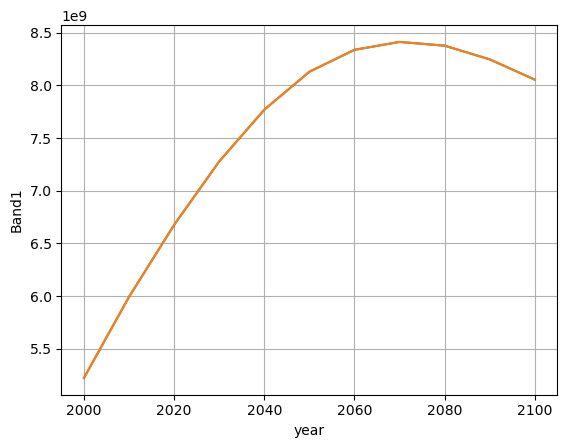

In [8]:
weighted_sum(new_pop).plot()
weighted_sum(pop_ssp2).plot()
plt.grid()